In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

data = data.dropna(subset=["TotalCharges"]).copy()

data["ChurnFlag"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("Dataset prepared successfully!")
print("Rows:", len(data))

Dataset prepared successfully!
Rows: 7032


In [3]:
# Predictive features

features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X = data[features]
y = data["ChurnFlag"]

print("Features:", features)
print("Target: ChurnFlag")
print("Feature shape:", X.shape)

Features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Target: ChurnFlag
Feature shape: (7032, 3)


In [4]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5625
Testing samples: 1407


In [5]:
# Scale features and train Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Predictive risk model trained successfully!")

Predictive risk model trained successfully!


In [6]:
# Predict churn probability

data["ChurnProbability"] = model.predict_proba(
    scaler.transform(data[features])
)[:, 1]

print("Churn probabilities calculated!")
print(data[["customerID", "ChurnProbability"]].head())

Churn probabilities calculated!
   customerID  ChurnProbability
0  7590-VHVEG          0.313027
1  5575-GNVDE          0.134850
2  3668-QPYBK          0.474245
3  7795-CFOCW          0.046463
4  9237-HQITU          0.603513


In [7]:
# Assign customer risk levels

def assign_risk(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

data["RiskLevel"] = data["ChurnProbability"].apply(assign_risk)

risk_summary = data["RiskLevel"].value_counts()

print("Customer Risk Distribution")
print("--------------------------")
print(risk_summary)

Customer Risk Distribution
--------------------------
RiskLevel
Low Risk       5079
Medium Risk    1731
High Risk       222
Name: count, dtype: int64


In [8]:
# Rank customers by churn probability

risk_ranking = data[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn",
        "ChurnProbability",
        "RiskLevel"
    ]
].sort_values(
    "ChurnProbability",
    ascending=False
).reset_index(drop=True)

risk_ranking["RiskRank"] = (
    risk_ranking.index + 1
)

risk_ranking.head(20)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn,ChurnProbability,RiskLevel,RiskRank
0,2081-VEYEH,3,107.95,318.60,No,0.820644,High Risk,1
1,5760-IFJOZ,3,107.95,313.60,No,0.820559,High Risk,2
2,1875-QIVME,2,104.40,242.80,Yes,0.812611,High Risk,3
3,1400-MMYXY,3,105.90,334.65,Yes,0.811458,High Risk,4
4,7181-BQYBV,1,102.45,102.45,Yes,0.810798,High Risk,5
5,5052-PNLOS,3,105.35,323.25,Yes,0.808654,High Risk,6
6,3992-YWPKO,6,109.90,669.45,Yes,0.806633,High Risk,7
7,6496-SLWHQ,3,105.00,294.45,Yes,0.806467,High Risk,8
8,5419-JPRRN,1,101.45,101.45,Yes,0.806017,High Risk,9
9,7216-EWTRS,1,100.80,100.80,Yes,0.802860,High Risk,10


In [9]:
# Model evaluation

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("MODEL PERFORMANCE")
print("-------------------------")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("ROC-AUC:", round(roc_auc, 4))

MODEL PERFORMANCE
-------------------------
Accuracy: 0.7747
Precision: 0.6059
Recall: 0.4358
ROC-AUC: 0.8111


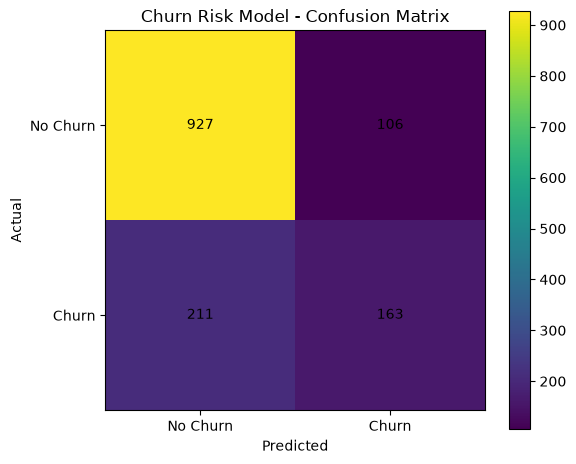

In [10]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Churn Risk Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

plt.savefig(
    "day41_confusion_matrix.png",
    dpi=300
)

plt.show()

In [11]:
# Save model performance

model_performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        roc_auc
    ]
})

model_performance = model_performance.round(4)

model_performance.to_csv(
    "day41_model_performance.csv",
    index=False
)

print("Model performance saved successfully!")

Model performance saved successfully!


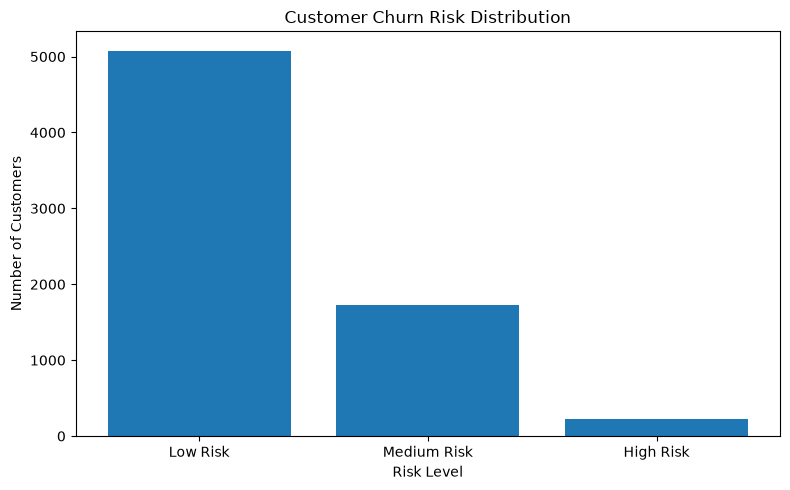

In [12]:
# Customer Risk Distribution

risk_counts = data["RiskLevel"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "day41_risk_distribution.png",
    dpi=300
)

plt.show()

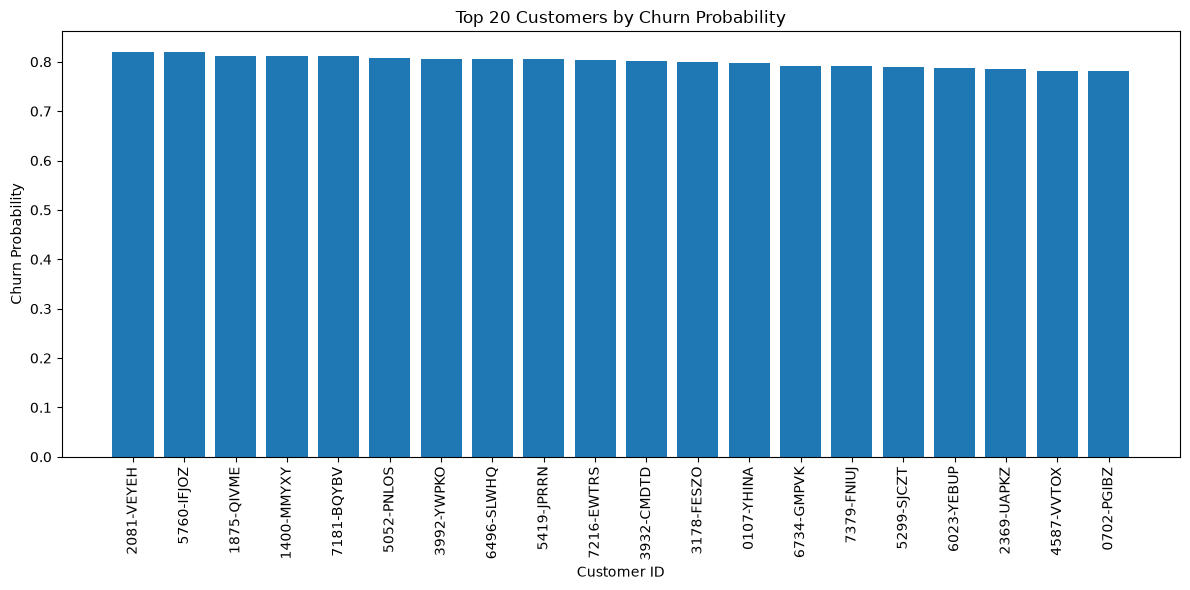

In [13]:
# Top 20 Highest-Risk Customers

top_risk = risk_ranking.head(20)

plt.figure(figsize=(12, 6))

plt.bar(
    top_risk["customerID"].astype(str),
    top_risk["ChurnProbability"]
)

plt.title("Top 20 Customers by Churn Probability")
plt.xlabel("Customer ID")
plt.ylabel("Churn Probability")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "day41_top_risk_customers.png",
    dpi=300
)

plt.show()

In [14]:
# Identify high-risk customers

high_risk = data[data["RiskLevel"] == "High Risk"]

medium_risk = data[data["RiskLevel"] == "Medium Risk"]

low_risk = data[data["RiskLevel"] == "Low Risk"]

print("HIGH RISK CUSTOMERS:", len(high_risk))
print("MEDIUM RISK CUSTOMERS:", len(medium_risk))
print("LOW RISK CUSTOMERS:", len(low_risk))

HIGH RISK CUSTOMERS: 222
MEDIUM RISK CUSTOMERS: 1731
LOW RISK CUSTOMERS: 5079


In [15]:
# Business retention recommendations

recommendation_report = f"""
DAY 41 — PREDICTIVE CUSTOMER RISK REPORT
========================================

RISK DISTRIBUTION
-----------------
High Risk Customers: {len(high_risk)}
Medium Risk Customers: {len(medium_risk)}
Low Risk Customers: {len(low_risk)}

MODEL PERFORMANCE
-----------------
Accuracy: {accuracy:.4f}
Precision: {precision:.4f}
Recall: {recall:.4f}
ROC-AUC: {roc_auc:.4f}

RETENTION STRATEGIES
--------------------

HIGH-RISK CUSTOMERS
- Prioritize proactive retention outreach.
- Review service issues and customer experience.
- Consider personalized offers where appropriate.
- Monitor these customers closely.

MEDIUM-RISK CUSTOMERS
- Use targeted engagement campaigns.
- Monitor changes in usage and charges.
- Provide relevant service and support options.

LOW-RISK CUSTOMERS
- Maintain regular engagement.
- Encourage long-term loyalty.
- Monitor their risk scores for future changes.

BUSINESS INTERPRETATION
-----------------------
The predictive system ranks customers according to estimated churn
probability. Risk scores can help prioritize retention resources,
but they should be treated as model estimates rather than certain
predictions of future customer behavior.

RECOMMENDATION
--------------
Use the risk ranking as a decision-support tool and periodically
retrain and validate the model using newer customer data.
"""

print(recommendation_report)

with open(
    "day41_business_recommendation_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(recommendation_report)

print("Business recommendation report saved successfully!")


DAY 41 — PREDICTIVE CUSTOMER RISK REPORT

RISK DISTRIBUTION
-----------------
High Risk Customers: 222
Medium Risk Customers: 1731
Low Risk Customers: 5079

MODEL PERFORMANCE
-----------------
Accuracy: 0.7747
Precision: 0.6059
Recall: 0.4358
ROC-AUC: 0.8111

RETENTION STRATEGIES
--------------------

HIGH-RISK CUSTOMERS
- Prioritize proactive retention outreach.
- Review service issues and customer experience.
- Consider personalized offers where appropriate.
- Monitor these customers closely.

MEDIUM-RISK CUSTOMERS
- Use targeted engagement campaigns.
- Monitor changes in usage and charges.
- Provide relevant service and support options.

LOW-RISK CUSTOMERS
- Maintain regular engagement.
- Encourage long-term loyalty.
- Monitor their risk scores for future changes.

BUSINESS INTERPRETATION
-----------------------
The predictive system ranks customers according to estimated churn
probability. Risk scores can help prioritize retention resources,
but they should be treated as model est

In [16]:
# Save customer risk ranking

risk_ranking.to_csv(
    "day41_customer_risk_ranking.csv",
    index=False
)

print("Customer risk ranking saved successfully!")

Customer risk ranking saved successfully!


In [17]:
# Save risk group summary

risk_group_summary = data.groupby("RiskLevel").agg(
    CustomerCount=("customerID", "count"),
    AverageChurnProbability=("ChurnProbability", "mean"),
    AverageTenure=("tenure", "mean"),
    AverageMonthlyCharges=("MonthlyCharges", "mean")
).reset_index()

risk_group_summary["AverageChurnProbability"] = (
    risk_group_summary["AverageChurnProbability"] * 100
)

risk_group_summary = risk_group_summary.round(2)

risk_group_summary.to_csv(
    "day41_risk_group_summary.csv",
    index=False
)

risk_group_summary

,RiskLevel,CustomerCount,AverageChurnProbability,AverageTenure,AverageMonthlyCharges
0,High Risk,222,74.09,4.24,95.07
1,Low Risk,5079,15.13,41.14,59.13
2,Medium Risk,1731,54.26,10.46,77.56
